In [ ]:
%load_ext autoreload
%autoreload 2
from api_keys import OPENAI_API_KEY, GOOGLE_API_KEY
import os 
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY



from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

import sciexplorer
from sciexplorer.tools.coding_tools import execute_code, plot_from_code
from sciexplorer.runs.human_in_the_loop import run_human_in_the_loop


/Users/mnaegel/anaconda3/envs/sciexp_v2/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
model = ChatOpenAI(model="gpt-5")
#model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

# set model type for API-specific printing and image handling
sciexplorer.utils.model_specifics.MODEL_TYPE = "openai"  # or "gemini"

In [4]:
system_prompt = """You are a cautious and curious scientist.
<tool_preambles>
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>"""
first_message = """
Can you please implement a function for training a simple dense neural network on MNIST in JAX and visualize the training curve and some example predictions before and after training."""

--binding tools ['execute_code', 'plot_from_code']--
SYSTEM TEXT: You are a cautious and curious scientist.
<tool_preambles>
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>
HUMAN TEXT: 
Can you please implement a function for training a simple dense neural network on MNIST in JAX and visualize the training curve and some example predictions before and after training.
Each tool has a maximum runtime of 300 seconds and is automatically terminated if it exceeds this limit.
AI REASONING: **Implementing code for MNIST**

I’m thinking we need to write some code to load the MNIST dataset, but I’m wondering if we should use sklearn or tensorflow for that. Given the tools we have in this JAX environment, sklearn seems to be the best option with `fetch_openml`. However, it looks like we might run into issues if the internet is blocked. Alternatively, I could use a smaller dataset, but the user specifically asked for MNIST. If

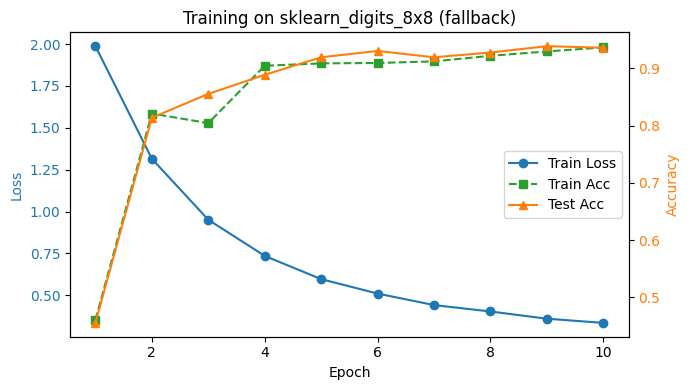

TOOL TEXT: Saved the following result in under <result_key>: <value> 
image: Image data.
TOOL IMAGE: <<Image 0>>
AI TEXT: Now I’ll create a grid of example images, annotating each with:
- True label
- Predicted label before training
- Predicted label after training

This will help visualize how predictions improve after training.
AI FUNCTION CALL: plot_from_code
  ARGUMENT code:
    import matplotlib.pyplot as plt
    import numpy as np
    
    n = example_images.shape[0]
    side = int(np.sqrt(example_images.shape[1]))
    cols = 4
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 7))
    axes = np.atleast_2d(axes)
    
    for i in range(rows * cols):
        r = i // cols
        c = i % cols
        ax = axes[r, c]
        ax.axis('off')
        if i < n:
            img = example_images[i].reshape(side, side)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"y={int(example_labels[i])}\npre={int(preds_pre[i])}  post={int(

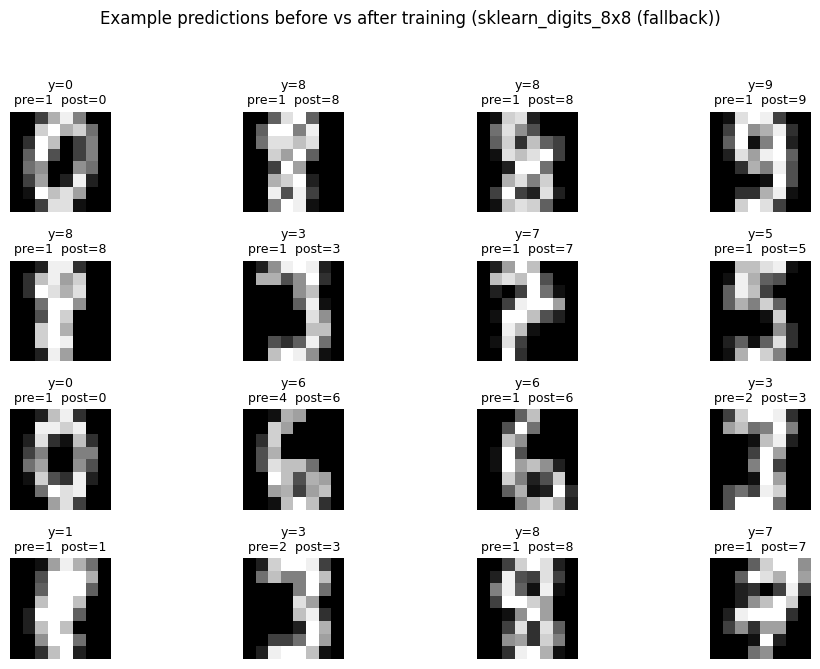

TOOL TEXT: Saved the following result in under <result_key>: <value> 
image: Image data.
TOOL IMAGE: <<Image 0>>
AI TEXT: I implemented and trained a simple dense neural network in JAX and produced two visualizations: the training curve and a grid of example predictions before and after training.

Notes on the dataset:
- I attempted to load MNIST via sklearn’s fetch_openml. If this download is not available in the environment, the code falls back to scikit-learn’s 8x8 digits dataset. In this run, the fallback dataset was used (sklearn_digits_8x8), which is smaller but suitable for demonstrating the pipeline.
- The network is a 2-layer MLP: input -> ReLU(256) -> logits(num_classes). It’s trained with mini-batch SGD.

What you can see in the outputs:
- Training curve: Displays training loss and both train and test accuracy over epochs. Accuracy improves steadily, reaching >90% test accuracy on the fallback dataset.
- Example predictions (before vs. after training): Shows a set of sample 

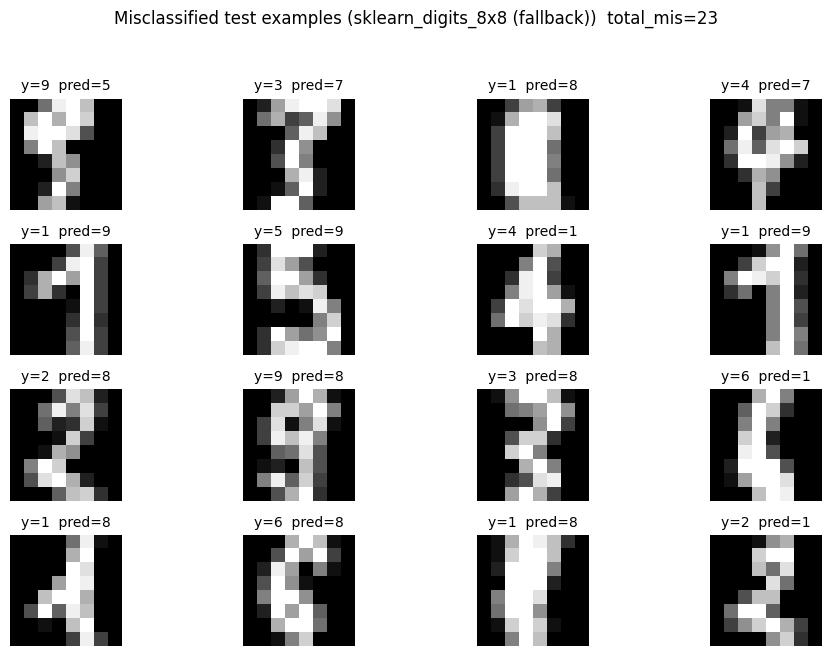

TOOL TEXT: Saved the following result in under <result_key>: <value> 
image: Image data.
TOOL IMAGE: <<Image 0>>
AI TEXT: I’ve plotted a grid of misclassified test examples from the trained model, showing for each:
- True label (y)
- Model’s incorrect prediction (pred)

What you can look for in the failures:
- Confusions between visually similar digits at this low 8x8 resolution, e.g., 1 vs 7, 3 vs 8, 4 vs 9.
- Ambiguous handwriting where strokes are faint or merged.
- The limitations of a simple MLP compared to convolutional models, especially on low-resolution images.

If you want deeper diagnostics, I can also:
- Plot a confusion matrix to see systematic confusions.
- Show class-conditional mistakes (e.g., all misclassified 9’s).
- Visualize intermediate activations or use simple saliency to see which pixels the network relied on.
- Switch to a CNN or use data augmentation to reduce specific failure modes.
HUMAN TEXT: END
--Exploration finished in 325.93 seconds.--
--Final result: N

In [ ]:
import functools
from sciexplorer.tools.tool_utils import run_with_timeout # wrapper to add timeouts to tool calls
timeout = 300 # seconds

final_state = run_human_in_the_loop(
        model = model, # The language model to use
        initial_message = first_message + "\nEach tool has a maximum runtime of " + str(timeout) + " seconds and is automatically terminated if it exceeds this limit.", # The initial message to the agent
        system_message = system_prompt, # The system prompt to guide the agent's behavior
        tools=[execute_code, plot_from_code], # tools to be used by the agent
        initial_fields=None, # Initial fields available eg. in the execute_code tool
        add_tools_to_fields = False, # Whether to add all tools as callable fields to the _fields dictionary, e.g. to call them from execute_code
        save_path= './example_results', # Path to save the results
        tool_wrapper = functools.partial(run_with_timeout, timeout=timeout),
        print_intermediate=True, # Whether to print intermediate messages
        print_long_arrays=False, # Whether to print long arrays into the agents context (as opposed to saving them and providing a summary only)
        invoke_kwargs={'reasoning': {'effort': "low",'summary': "auto"}, #kwargs passed when calling the model
                       'verbosity': 'high'},
        add_to_saved_dict = {'timeout': timeout}, # additional information to add to the saved dictionary,
        add_to_save_name = 'agentic_chat_', # string to add to the save file name
        ask_at_each_step = False, # Only ask the user for input if no tool calls were made in the last step
)